<a href="https://colab.research.google.com/github/walalakhider/Tp04-face-recognition-pca/blob/main/TP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**IMPORTS**

In [40]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from itertools import product

# Classe FaceRecognitionPCA

In [62]:
class FaceRecognitionPCA:

    def __init__(self, n_components=30):
        cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self.detector = cv2.CascadeClassifier(cascade_path)
        if self.detector.empty():
            raise RuntimeError("Impossible de charger la cascade Haar.")
        self.n_components = n_components
        self.mean_face    = None
        self.eigenvectors = None
        self.projections  = None
        self.labels       = []
        self.face_size    = (100, 100)

    def detect_face(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5,
            minSize=(30, 30), flags=cv2.CASCADE_SCALE_IMAGE
        )
        if len(faces) == 0:
            return None
        faces = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)
        x, y, w, h = faces[0]
        return cv2.resize(gray[y:y+h, x:x+w], self.face_size)

    def load_dataset(self, dataset_path):
        X, y = [], []
        dataset_path = Path(dataset_path)
        print(f"\nChargement du dataset : {dataset_path}")
        print("-" * 50)
        for person_dir in sorted(dataset_path.iterdir()):
            if not person_dir.is_dir():
                continue
            person_name = person_dir.name
            count = 0
            for img_path in sorted(person_dir.iterdir()):
                if img_path.suffix.lower() not in [".jpg",".jpeg",".png",".bmp"]:
                    continue
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"  Impossible de lire : {img_path.name}")
                    continue
                face = self.detect_face(img)
                if face is None:
                    print(f"  Aucun visage detecte : {img_path.name}")
                    continue
                X.append(face.flatten().astype(np.float64))
                y.append(person_name)
                count += 1
            print(f"  OK {person_name} : {count} image(s)")
        X = np.array(X)
        D = X.shape[1] if X.ndim > 1 and len(X) > 0 else 0
        print(f"  Matrice X : {X.shape}  (N={len(X)}, D={D})")
        print("-" * 50)
        return X, y

    def compute_pca(self, X):
        N, D = X.shape
        k = min(self.n_components, N - 1)
        self.mean_face = np.mean(X, axis=0)
        X_c = X - self.mean_face
        C   = X_c @ X_c.T
        eigenvalues, evecs_small = np.linalg.eigh(C)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        evecs_small  = evecs_small[:, idx]
        evecs_full   = X_c.T @ evecs_small
        norms = np.linalg.norm(evecs_full, axis=0, keepdims=True)
        norms[norms == 0] = 1
        evecs_full /= norms
        self.eigenvectors = evecs_full[:, :k].T
        total = np.sum(eigenvalues)
        var   = np.sum(eigenvalues[:k]) / total * 100 if total > 0 else 0
        print(f"  PCA calculee : k={k}, variance expliquee={var:.1f}%")

    def project(self, face_vector):
        return self.eigenvectors @ (face_vector - self.mean_face)

    def fit(self, X, y):
        self.compute_pca(X)
        self.labels      = y
        self.projections = np.array([self.project(x) for x in X])
        print(f"  Projections : {self.projections.shape}")

    def recognize(self, image, threshold=3000.0):
        result = {
            'identity'    : 'Unknown',
            'distance'    : float('inf'),
            'decision'    : 'No Match',
            'bbox'        : None,
            'face_detected': False
        }
        gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )
        if len(faces) == 0:
            print("Aucun visage detecte dans l'image de test.")
            return result
        faces = sorted(faces, key=lambda r: r[2]*r[3], reverse=True)
        x, y_c, w, h = faces[0]
        result['bbox']          = (x, y_c, w, h)
        result['face_detected'] = True
        face_vec  = cv2.resize(gray[y_c:y_c+h, x:x+w], self.face_size).flatten().astype(np.float64)
        face_proj = self.project(face_vec)
        dists     = np.linalg.norm(self.projections - face_proj, axis=1)
        idx       = np.argmin(dists)
        result['distance'] = dists[idx]
        result['identity'] = self.labels[idx]
        result['decision'] = 'Match' if dists[idx] < threshold else 'No Match'
        return result

print("Classe FaceRecognitionPCA OK.")

Classe FaceRecognitionPCA OK.


# Fonctions d'affichage

In [63]:
def display_result(image, result, title="Test"):
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
    if result['face_detected'] and result['bbox'] is not None:
        x, y, w, h = result['bbox']
        color = 'lime' if result['decision'] == 'Match' else 'red'
        ax.add_patch(patches.Rectangle((x,y), w, h,
                     linewidth=2, edgecolor=color, facecolor='none'))
        label = f"{result['identity']}\nDist:{result['distance']:.1f}\n{result['decision']}"
        ax.text(x, y-5, label, color=color, fontsize=9, fontweight='bold',
                va='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=2))
    plt.tight_layout()
    plt.show()


def show_mean_face(model):
    plt.figure(figsize=(3,3))
    plt.imshow(model.mean_face.reshape(model.face_size), cmap='gray')
    plt.title("Visage moyen")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def show_eigenfaces(model, n_show=8):
    k_show = min(n_show, model.eigenvectors.shape[0])
    fig, axes = plt.subplots(1, k_show, figsize=(2*k_show, 2.5))
    fig.suptitle("Eigenfaces", fontsize=13, fontweight='bold')
    if k_show == 1:
        axes = [axes]
    for i in range(k_show):
        ef = model.eigenvectors[i].reshape(model.face_size)
        ef = (ef - ef.min()) / (ef.max() - ef.min() + 1e-8)
        axes[i].imshow(ef, cmap='gray')
        axes[i].set_title(f"EF {i+1}", fontsize=8)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

print("Fonctions d'affichage OK.")

Fonctions d'affichage OK.


# EXPÉRIMENTATION 1 : EFFET DU NOMBRE DE COMPOSANTES k

In [64]:
def experiment_k_components(dataset_path, test_image_path,
                             k_values=None, threshold=3000.0):
    if k_values is None:
        k_values = [3, 5, 7]
    print("\n" + "="*55)
    print("  EXPERIMENTATION : Effet de k")
    print("="*55)
    test_img = cv2.imread(test_image_path)
    if test_img is None:
        print(f"Image introuvable : {test_image_path}")
        return
    results_k = {}
    for k in k_values:
        print(f"\n--- k = {k} ---")
        m = FaceRecognitionPCA(n_components=k)
        X, y = m.load_dataset(dataset_path)
        if X.shape[0] == 0:
            continue
        m.fit(X, y)
        results_k[k] = m.recognize(test_img, threshold=threshold)
    print("\n" + "-"*55)
    print(f"  {'k':>4}  {'Identite':<14} {'Distance':>10}  {'Decision'}")
    print("-"*55)
    for k, res in results_k.items():
        print(f"  {k:>4}  {res['identity']:<14} {res['distance']:>10.2f}  {res['decision']}")
    print("-"*55)
    return results_k

print("experiment_k_components OK.")

experiment_k_components OK.


# EXPÉRIMENTATION 2 : EFFET DU SEUIL (Distance vs Décision)

In [65]:
def experiment_threshold(model, test_images, thresholds=None):
    if thresholds is None:
        thresholds = [500, 1000, 2000, 3000, 5000, 8000]
    print("\n" + "="*70)
    print("  EXPERIMENTATION : Effet du seuil (Distance vs Decision)")
    print("="*70)

    # Calcul des distances
    test_results = []
    for img_path, true_label in test_images:
        img = cv2.imread(img_path)
        if img is None:
            print(f"  Image introuvable : {img_path}")
            continue
        res = model.recognize(img, threshold=999999)
        status = "OK" if res['face_detected'] else "NO FACE"
        print(f"  {Path(img_path).name:<25} dist={res['distance']:>8.1f}  pred={res['identity']:<12} vrai={true_label}  [{status}]")
        if res['face_detected']:
            test_results.append({
                'path': img_path,
                'true_label': true_label,
                'pred_label': res['identity'],
                'distance'  : res['distance']
            })

    if not test_results:
        print("  Aucune image de test valide.")
        return

    # Tableau Distance vs Decision
    print("\n" + "-"*70)
    print(f"  {'Image':<25} {'Dist':>8}", end="")
    for t in thresholds:
        print(f"  {t:>6}", end="")
    print()
    print("-"*70)
    for r in test_results:
        fname = Path(r['path']).name[:23]
        print(f"  {fname:<25} {r['distance']:>8.1f}", end="")
        for t in thresholds:
            print(f"  {'Match' if r['distance']<t else 'NoMat':>6}", end="")
        print()
    print("-"*70)

    # Metriques
    print(f"\n  {'Seuil':>8}  {'Taux_Reco%':>10}  {'Faux_Rejets':>12}  {'Fausses_Accept':>15}")
    print("  " + "-"*52)
    for t in thresholds:
        correct = fr = fa = 0
        for r in test_results:
            match      = r['distance'] < t
            correct_id = r['pred_label'] == r['true_label']
            if match and correct_id:       correct += 1
            elif not match and correct_id: fr += 1
            elif match and not correct_id: fa += 1
        n = len(test_results)
        print(f"  {t:>8.0f}  {correct/n*100:>10.1f}  {fr:>12}  {fa:>15}")
    print()
    return test_results

print("experiment_threshold OK.")

experiment_threshold OK.


# PROGRAMME PRINCIPAL

TP04 - Reconnaissance Faciale PCA (Eigenfaces)

Chargement du dataset : /content/drive/MyDrive/tp4/dataset
--------------------------------------------------
  OK person1 : 5 image(s)
  OK person2 : 5 image(s)
  Matrice X : (10, 10000)  (N=10, D=10000)
--------------------------------------------------
  PCA calculee : k=7, variance expliquee=92.0%
  Projections : (10, 7)


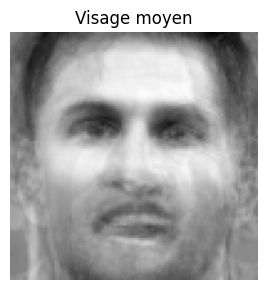

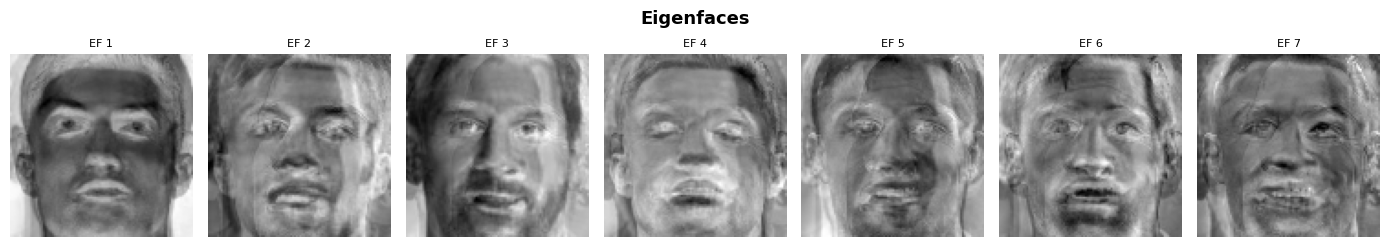


  TESTS DE RECONNAISSANCE

  test_cristiano (attendu : person1)
    Distance : 3266.37
    Identite : person2
    Decision : No Match


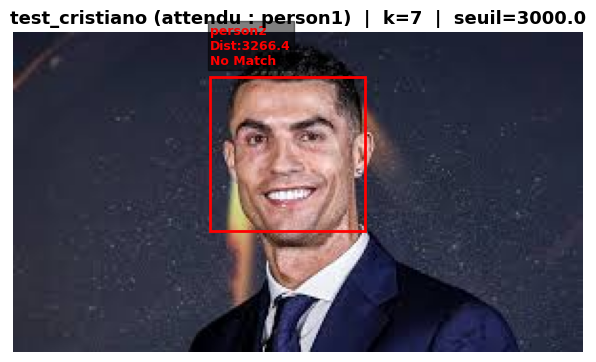


  test_messi     (attendu : person2)
    Distance : 427.28
    Identite : person2
    Decision : Match


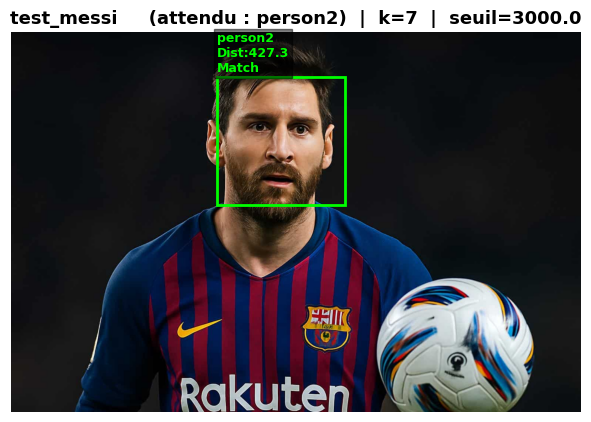


  test_inconnu   (attendu : No Match)
    Distance : 3723.84
    Identite : person1
    Decision : No Match


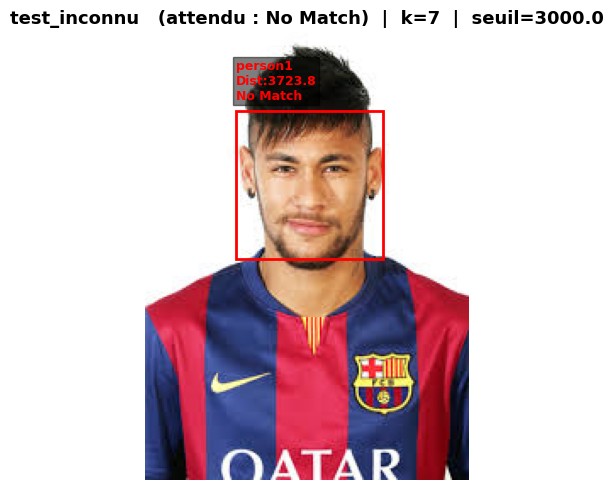


  EXPERIMENTATION : Effet de k

--- k = 3 ---

Chargement du dataset : /content/drive/MyDrive/tp4/dataset
--------------------------------------------------
  OK person1 : 5 image(s)
  OK person2 : 5 image(s)
  Matrice X : (10, 10000)  (N=10, D=10000)
--------------------------------------------------
  PCA calculee : k=3, variance expliquee=59.6%
  Projections : (10, 3)

--- k = 5 ---

Chargement du dataset : /content/drive/MyDrive/tp4/dataset
--------------------------------------------------
  OK person1 : 5 image(s)
  OK person2 : 5 image(s)
  Matrice X : (10, 10000)  (N=10, D=10000)
--------------------------------------------------
  PCA calculee : k=5, variance expliquee=78.9%
  Projections : (10, 5)

--- k = 7 ---

Chargement du dataset : /content/drive/MyDrive/tp4/dataset
--------------------------------------------------
  OK person1 : 5 image(s)
  OK person2 : 5 image(s)
  Matrice X : (10, 10000)  (N=10, D=10000)
--------------------------------------------------
  PCA calc

In [67]:
def main():
    # ── Chemins ────────────────────────────────────────────────────
    DATASET_PATH = "/content/drive/MyDrive/tp4/dataset"
    TEST_DIR     = "/content/drive/MyDrive/tp4/test"

    # Images de test séparées de l'entraînement
    TEST_CRISTIANO = f"{TEST_DIR}/test_cristiano.jpg"
    TEST_MESSI     = f"{TEST_DIR}/test_messi.jpeg"
    TEST_INCONNU   = f"{TEST_DIR}/test_inconnu.jpg"

    K         = 7        # k <= N-1 = 7 avec 8 images d'entraînement
    THRESHOLD = 3000.0

    print("TP04 - Reconnaissance Faciale PCA (Eigenfaces)")
    print("=" * 55)

    # ── ETAPE 1 : Chargement ───────────────────────────────────────
    model = FaceRecognitionPCA(n_components=K)
    X, y  = model.load_dataset(DATASET_PATH)

    if X.shape[0] == 0:
        print("Aucune image valide chargee.")
        return

    # ── ETAPE 2 : Modele PCA ───────────────────────────────────────
    model.fit(X, y)
    show_mean_face(model)
    show_eigenfaces(model, n_show=min(8, K))

    # ── ETAPE 3 : Tests sur les 3 images séparées ──────────────────
    print("\n" + "="*55)
    print("  TESTS DE RECONNAISSANCE")
    print("="*55)

    test_cases = [
        (TEST_CRISTIANO, "test_cristiano (attendu : person1)"),
        (TEST_MESSI,     "test_messi     (attendu : person2)"),
        (TEST_INCONNU,   "test_inconnu   (attendu : No Match)"),
    ]

    for img_path, description in test_cases:
        img = cv2.imread(img_path)
        if img is None:
            print(f"\n  Image introuvable : {img_path}")
            continue
        result = model.recognize(img, threshold=THRESHOLD)
        print(f"\n  {description}")
        print(f"    Distance : {result['distance']:.2f}")
        print(f"    Identite : {result['identity']}")
        print(f"    Decision : {result['decision']}")
        display_result(img, result, title=f"{description}  |  k={K}  |  seuil={THRESHOLD}")

    # ── ETAPE 4 : Expérimentation k ────────────────────────────────
    # Avec N=8, k max = 7  →  on compare k=3, 5, 7
    experiment_k_components(
        dataset_path    = DATASET_PATH,
        test_image_path = TEST_CRISTIANO,
        k_values        = [3, 5, 7],
        threshold       = THRESHOLD
    )

    # ── ETAPE 5 : Expérimentation seuil ───────────────────────────
    # true_label = 'person1' ou 'person2' ou 'unknown'
    test_images_for_threshold = [
        (TEST_CRISTIANO, "person1"),
        (TEST_MESSI,     "person2"),
        (TEST_INCONNU,   "unknown"),
    ]
    experiment_threshold(
        model       = model,
        test_images = test_images_for_threshold,
        thresholds  = [500, 1000, 2000, 3000, 5000, 8000]
    )

main()